## Housing Prices Analysis Practice with Ridge/Lasso Regression and Random Forests ##
Inaya Rizvi


In [3]:
# unzipping housing dataset 
import zipfile 
with zipfile.ZipFile("house-prices-advanced-regression-techniques.zip", 'r') as zip_ref:
    zip_ref.extractall("housing_data")

In [4]:
# loading training dataset into pandas
import pandas as pd 

df = pd.read_csv("housing_data/train.csv")
print("Full training dataset shape is {}".format(df.shape))
df.head(30)

Full training dataset shape is (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


#### Cleaning and Preparing Data for Training ####

In [5]:
# handling missing values

import pandas as pd
import numpy as np

# checking for missing values 
missing_values = df.isnull().sum() # count missing values per column
missing_values[missing_values > 0].sort_values(ascending=False) # only show cols with missing vals

# fill missing numeric values with median
num_features = df.select_dtypes(include=['int64', 'float64']).columns
df[num_features] = df[num_features].fillna(df[num_features].median())

cat_features = df.select_dtypes(include=['object']).columns
df[cat_features] = df[cat_features].fillna("Missing")

# checking df now that we replaced null values
if df.isnull().sum().sum() == 0:
    print("All missing values handled.")
else: 
    print("Some missing values remain")
    missing_values[missing_values > 0].sort_values(ascending=False)

#print(df['SalePrice'])

All missing values handled.


In [6]:
# encoding categorical variables 

df = pd.get_dummies(df, columns=cat_features, drop_first=True)

# convert boolean values (from encoding) to ints
df = df.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)
df.head() # to see new columns 


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,0,0,0,0,1,0,0,0,1,0


Now, the data has been cleaned and preprocessed. To recap, we: 
- ensured there were no null values 
- used dummy variables to convert categorical attributes into numerical (necessary for  regression) 

#### Visualizing the Data to Check for Multicollinearity ####

Highly Correlated Feature Pairs (>|0.6|):
PoolQC_Missing         PoolArea                 0.989665
PoolArea               PoolQC_Missing           0.989665
SaleType_New           SaleCondition_Partial    0.986819
SaleCondition_Partial  SaleType_New             0.986819
BsmtFinType2_Missing   BsmtFinType1_Missing     0.986408
                                                  ...   
Foundation_PConc       BsmtQual_TA              0.603797
BsmtUnfSF              BsmtFinType1_Unf         0.602707
BsmtFinType1_Unf       BsmtUnfSF                0.602707
OverallQual            GarageCars               0.600671
GarageCars             OverallQual              0.600671
Length: 198, dtype: float64
Total number of unique features with high correlations: 110


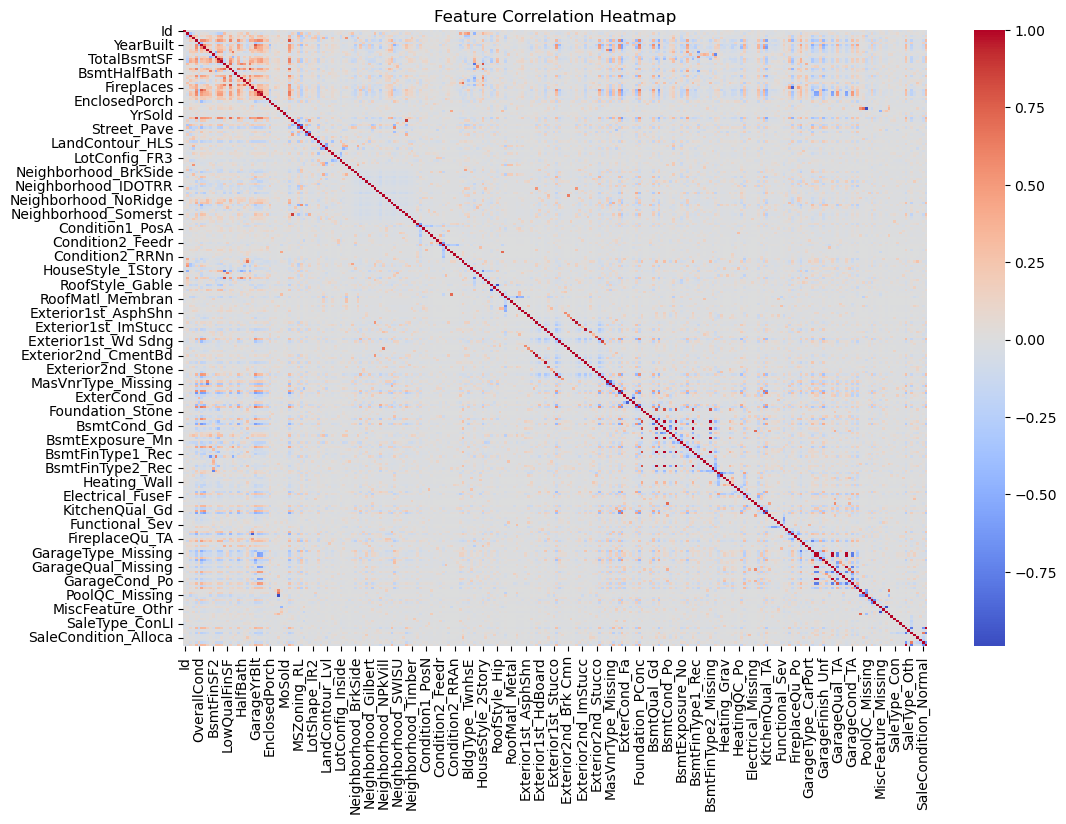

In [7]:
# correlation heatmap to check for multicollinearity

import seaborn as sns
import matplotlib.pyplot as plt

# computing correlation matrix
corr_matrix = df.corr()

# sorting correlated pairs from most to least correlated 
high_corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)

# removing self-correlations 
high_corr_pairs = high_corr_pairs[high_corr_pairs < 1]

# setting |0.6| as the threshold from strong correlations 
high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.6]

num_high_corr_pairs = high_corr_pairs.shape[0] // 2 # each pair appears twice, so divide by 2

print("Highly Correlated Feature Pairs (>|0.6|):")
print(high_corr_pairs)

# getting set of individual features are in high correlation pairs by
# creating set of the first features from each correlated pair, and a set of the second features,
# then creating a union of both sets for all unique features
unique_high_corr_features = set(high_corr_pairs.index.get_level_values(0)) | set(high_corr_pairs.index.get_level_values(1))

# counting unique high-correlation features
num_unique_features = len(unique_high_corr_features)

print(f"Total number of unique features with high correlations: {num_unique_features}")

# plotting heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

As seen in the above correlation matrix and heatmap, **110 features in this dataset exhibit high multicollinearity,** meaning they are strongly correlated with each other. This can cause Ordinary Least Squares (OLS) regression to assign unstable or inflated coefficients, leading to overfitting and unreliable predictions.

To address this, I will use Ridge Regression, which applies L2 regularization to penalize large coefficients and improve model stability, ensuring better generalization to unseen data.

#### Training Ridge Regression ####

3 steps: 
 1. Train a baseline model with alpha=1.0
 2. Cross-validate to find the best alpha
 3. Train regression with the best alpha

In [8]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


# defining features (Xs) and target (y)
X_train = df.drop(columns=["SalePrice"]) # dropping target variable
y_train = df["SalePrice"] # target variable


# creating a pipeline to standardize then fitting the baseline ridge model (alpha = 1.0)
ridge_model = make_pipeline(StandardScaler(),Ridge(alpha=1.0))
ridge_model.fit(X_train, y_train)

# predict on training set 
y_train_pred = ridge_model.predict(X_train)

# Evaluate RMSE

rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"Baseline Ridge Regression RMSE (alpha=1.0): {rmse:.4f}")

Baseline Ridge Regression RMSE (alpha=1.0): 20545.2565


Cross-validating alphas to minimize RMSE:

Process:
- 1. define range of alpha values to test
- 2. use 5-fold cross-validation to evaluate RMSE for each alpha
- 3. find alpha that gives lowest RMSE


In [9]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import numpy as np

# Defining KFold with shuffle=True and the same random_state
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Defining range of alpha values (logarithmic scale)
alpha_values = np.logspace(-3, 3, 10)  # test values from 0.001 to 1000
best_alpha_ridge = None
best_rmse_ridge = float('inf')

# Iterating over each alpha value to perform 5-fold cross-validation
for alpha in alpha_values:
    ridge = make_pipeline(StandardScaler(), Ridge(alpha=alpha))

    # Compute RMSE through 5-fold cross-validation
    rmse_scores = -cross_val_score(ridge, X_train, y_train,
                                   scoring='neg_root_mean_squared_error', cv=kf)

    mean_rmse = np.mean(rmse_scores)

    print(f"Alpha: {alpha:.4f}, RMSE: {mean_rmse:.4f}")

    # Update best alpha if current RMSE is lower
    if mean_rmse < best_rmse_ridge:
        best_rmse_ridge = mean_rmse
        best_alpha_ridge = alpha

print(f"\nBest Alpha: {best_alpha_ridge:.4f}, Best RMSE: {best_rmse_ridge:.4f}")


Alpha: 0.0010, RMSE: 47483.1860
Alpha: 0.0046, RMSE: 46911.6450
Alpha: 0.0215, RMSE: 44754.0840
Alpha: 0.1000, RMSE: 40140.3296
Alpha: 0.4642, RMSE: 37939.5956
Alpha: 2.1544, RMSE: 37529.7002
Alpha: 10.0000, RMSE: 35966.7082
Alpha: 46.4159, RMSE: 35049.6928
Alpha: 215.4435, RMSE: 34370.2542
Alpha: 1000.0000, RMSE: 34459.8208

Best Alpha: 215.4435, Best RMSE: 34370.2542


In [10]:
# verifying that best RMSE is reasonable 

print(f"Mean SalePrice: {y_train.mean():.2f}")
print(f"Percentage Ridge RMSE (best alpha = 215.4435): {(best_rmse_ridge / y_train.mean()) * 100:.2f}%")


Mean SalePrice: 180921.20
Percentage Ridge RMSE (best alpha = 215.4435): 19.00%


The most accurate ridge model thus far has an RMSE that is 19% of the average sale price of a house (the y variable), indicating that this model is performing reasonably well. However, I want to find a model with a bit more accuracy, so I will train a Lasso Regression model to see if feature selection and reducing some coefficients to 0 will help meaningfully reduce the RMSE to improve the model.   

### Implementing Lasso Regression for Feature Selection and Optimizing RMSE ####

In [11]:
# running baseline Lasso Regression model

from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np


# creating a pipeline to standardize then fitting baseline Lasso model (alpha = 1.0)
lasso_model = make_pipeline(StandardScaler(), Lasso(alpha=1.0, max_iter=50000))
lasso_model.fit(X_train, y_train) 

# predicting on training set 
y_train_pred = lasso_model.predict(X_train)

# evaluating RMSE

rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"Baseline Lasso Regression RMSE (alpha=1.0): {rmse:4f}")

Baseline Lasso Regression RMSE (alpha=1.0): 20513.937915


In [12]:
# cross-validation to find the best alpha for Lasso Regression model
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np

alpha_values = np.logspace(3,4,10) # from 1 to 1000
best_alpha_lasso = None
best_rmse_lasso = float('inf')

# iterating over each alpha value to perform cross-validation
for alpha in alpha_values: 
    lasso = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=50000))

    # computing RMSE through 5-fold cross-validation
    rmse = -np.mean(cross_val_score(lasso, X_train, y_train, 
                                    scoring='neg_root_mean_squared_error', cv=5))
    
    print(f"Alpha: {alpha:.4f}, RMSE: {rmse:.4f}")

    if rmse < best_rmse_lasso:
        best_rmse_lasso = rmse
        best_alpha_lasso = alpha

    
    
print(f"\nBest Alpha: {best_alpha_lasso}, Best RMSE: {best_rmse_lasso:.4f}")



Alpha: 1000.0000, RMSE: 32050.6122
Alpha: 1291.5497, RMSE: 32150.7122
Alpha: 1668.1005, RMSE: 32444.6729
Alpha: 2154.4347, RMSE: 33004.9138
Alpha: 2782.5594, RMSE: 33572.7256
Alpha: 3593.8137, RMSE: 34446.5302
Alpha: 4641.5888, RMSE: 35524.1259
Alpha: 5994.8425, RMSE: 36940.1443
Alpha: 7742.6368, RMSE: 38434.0032
Alpha: 10000.0000, RMSE: 40093.8075

Best Alpha: 1000.0, Best RMSE: 32050.6122


In [13]:

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline 
from sklearn.preprocessing import StandardScaler
import numpy as np

# define KFold with shufflee=True for consistency with Ridge
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# define range of alpha values for Lasso (log scale)
alpha_values = np.logspace(3,4,10) # from 1,000 to 10,000
best_alpha_lasso = None
best_rmse_lasso = float('inf')

# iterating over each alpha to do cross-validation
for alpha in alpha_values:
    lasso = make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=50000))

    # compute RMSE through 5-fold cross-validation with explicit KFold
    rmse_scores = -cross_val_score(lasso, X_train, y_train, 
                                   scoring='neg_root_mean_squared_error', cv=kf)
    
    mean_rmse = np.mean(rmse_scores)

    # updating best alpha if current RMSE is lower
    if mean_rmse < best_rmse_lasso:
        best_rmse_lasso = mean_rmse
        best_alpha_lasso = alpha

print(f"\nBest Alpha: {best_alpha_lasso}, Best RMSE: {best_rmse_lasso:.4f}")


Best Alpha: 1291.549665014884, Best RMSE: 35319.1718


In [14]:
# verifying that best Lasso RMSE is reasonable 

print(f"Mean SalePrice: {y_train.mean():.2f}")
print(f"Percentage Lasso RMSE (best alpha = 1291.549665014884): {(best_rmse_lasso / y_train.mean()) * 100:.2f}%")


Mean SalePrice: 180921.20
Percentage Lasso RMSE (best alpha = 1291.549665014884): 19.52%


The most accurate lasso model thus far has an RMSE that is 19.52% of the average sale price of a house (the y variable), indicating that this model is performing reasonably well. However, the ridge model's best alpha had an RMSE OF 19.00%, which tells us that Ridge Regression is actually the better performing model in this case. 

In [15]:
# retrieving the feature coefficients to see which features the Lasso Regression
# model is eliminating

best_lasso = make_pipeline(StandardScaler(), Lasso(alpha=best_alpha_lasso, max_iter=50000))
best_lasso.fit(X_train, y_train)

# extracting feature names and corresponding coeffs
feature_names = X_train.columns
lasso_coefficients = best_lasso.named_steps["lasso"].coef_

# creating a pandas df to visualize 
import pandas as pd
coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": lasso_coefficients})

# filtering out features eliminated by Lasso (coefs = 0)
eliminated_features = coef_df[coef_df["Coefficient"] == 0]["Feature"].tolist()
non_eliminated_features = coef_df[coef_df["Coefficient"] != 0]["Feature"].tolist()

# showing eliminated features 
print(f"Lasso eliminated {len(eliminated_features)} features:")
print(eliminated_features)

print(f"Lasso did not eliminate {len(non_eliminated_features)} features:")
print(non_eliminated_features)

Lasso eliminated 190 features:
['Id', 'LotFrontage', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF', 'BsmtHalfBath', 'HalfBath', 'BedroomAbvGr', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'MiscVal', 'MoSold', 'YrSold', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'Alley_Missing', 'Alley_Pave', 'LotShape_Reg', 'LandContour_Low', 'LandContour_Lvl', 'Utilities_NoSeWa', 'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Timber', 'Condition1_Feedr', 'Condition1_PosA', 'Condition1_PosN', 'Condition1_RRAe', 'Condition1_RRAn', 'Condition1_RRNe', 'Condition1_RRNn', 'Condition2_Feedr', 'Condition2_Norm', 'Condition2_R

#### Understanding Lasso vs. Ridge Regression ####

Lasso uses L1 regularization, which shrinks some feature coefficients to 0 to remove them from the model. After running Lasso Regression, I found that it removed 190 features, including:

- Numeric predictors: LotFrontage, 1stFlrSF, HalfBath, OpenPorchSF

- Categorical variables: MSZoning_RL, Neighborhood_Sawyer, BldgType_TwnhsE

- Other potentially useful features: YearSold, MoSold, FireplaceQu_TA, GarageType_Attchd

Even though feature selection can improve model performance, Lasso's aggressive elimination of features still had a higher RMSE, which suggests that it removed some variables that still contributed useful predictive power. 

**Ridge Regression is the better choice because:**
- It preserves all features while shrinking impact, so it maintains valuable information.
- It did have a lower RMSE, which means it's better suited to this dataset.
- Ridge is more stables when features are correlated, which is the case here.


**Overall,** Ridge Regression produced a lower RMSE and retained all predictive features. Lasso Regression's aggressive feature selection was too strong and led to the loss of important predictors and worse accuracy. 

I will now be training a Random Forests model on the data to assess its performance compared to the Ridge Regression model. It can potentially lower RMSE even more and automatically select features. 

#### Training the Random Forests Model ####

Steps: 
- 1. Train a baseline model and evaluate the RMSE
- 2. Perform cross-validation to get a better estimate and a more reliable RMSE
- 3. fine-tune hyperparameters to improve model

In [16]:
# training baseline model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error 
import numpy as np

# training baseline Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42) # starting with 100 trees
rf.fit(X_train, y_train)

# predicting on training set 
y_train_pred_rf = rf.predict(X_train)

# compute RMSE 
rf_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))

print(f"Baseline Random Forest RMSE: {rf_rmse:.4f}")

Baseline Random Forest RMSE: 11151.4189


In [17]:
# cross-validation to get a more reliable RMSE

from sklearn.model_selection import cross_val_score 

cv_rmse = -np.mean(cross_val_score(rf, X_train, y_train,
                                   scoring='neg_root_mean_squared_error', cv=5))

print(f"Cross-Validation RMSE for Random Forest: {cv_rmse:.4f}")

Cross-Validation RMSE for Random Forest: 30089.0966


In [18]:
# fine-tuning hyperparameters with a basic grid search

from sklearn.model_selection import GridSearchCV

# define hyperaparameter grid 
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 12, 15],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [4, 7, 10],
    'max_features': [1.0, 'sqrt', 'log2']
}

# initializing Random Forest
rf_tuned = RandomForestRegressor(random_state=42)

# performing grid search
grid_search = GridSearchCV(rf_tuned, param_grid, scoring='neg_root_mean_squared_error',
                           n_jobs=1, verbose=1)
grid_search.fit(X_train, y_train)

# printing best params 
print(f"Best parameters: {grid_search.best_params_}")

# training with best model
best_rf = grid_search.best_estimator_

# evaluating RMSE
best_rf_rmse = -grid_search.best_score_
print(f"Best Cross-Validated RMSE for Random Forest: {best_rf_rmse:.4f}")


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best parameters: {'max_depth': 15, 'max_features': 1.0, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validated RMSE for Random Forest: 30751.8407


In [19]:
# retraining best Random Forests Model on entire training dataset

best_rf_model = RandomForestRegressor(
    max_depth=15, max_features=1.0, min_samples_leaf=4, min_samples_split=5, n_estimators=100, random_state=42
)
best_rf_model.fit(X_train, y_train)

y_train_pred_bestrf = best_rf_model.predict(X_train)
train_msre = np.sqrt(mean_squared_error(y_train, y_train_pred_bestrf))
print(f"Training RMSE: {train_msre:.4f}")

Training RMSE: 17927.9542


Looking at the Random Forest RMSE either cross-evaluated or trained, the RMSE is significantly lower than Ridge Regression's best RMSE of 32,050. 

However, looking at the large difference between the cross-validated RF RMSE and the RMSE on the full training data, there is potential overfitting. To assess this, I will run and evaluate the best RF model on the test data to see its real-world performance. If the test RMSE is much higher than the training RMSE, overfitting is confirmed and I will use Ridge Regression for safer predictions. 

#### Running Random Forests Model on Test Data ####


First I need to preprocess the test data the same way I preprocessed the training data. 

In [20]:
# loading testing dataset into pandas
import pandas as pd 

test_df = pd.read_csv("housing_data/test.csv")
print("Full testing dataset shape is {}".format(test_df.shape))
test_df.head(30)

Full testing dataset shape is (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
5,1466,60,RL,75.0,10000,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
6,1467,20,RL,NaN,7980,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,GdPrv,Shed,500,3,2010,WD,Normal
7,1468,60,RL,63.0,8402,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
8,1469,20,RL,85.0,10176,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2010,WD,Normal
9,1470,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,4,2010,WD,Normal


In [21]:
# handling missing values

import pandas as pd
import numpy as np

# checking for missing values 
missing_values_test = test_df.isnull().sum() # count missing values per column
missing_values_test[missing_values_test > 0].sort_values(ascending=False) # only show cols with missing vals

# fill missing numeric values with median
num_features_test = test_df.select_dtypes(include=['int64', 'float64']).columns
test_df[num_features_test] = test_df[num_features_test].fillna(df[num_features_test].median())

cat_features_test = test_df.select_dtypes(include=['object']).columns
test_df[cat_features_test] = test_df[cat_features_test].fillna("Missing")

# checking df now that we replaced null values
if test_df.isnull().sum().sum() == 0:
    print("All missing values handled.")
else: 
    print("Some missing values remain")
    missing_values_test[missing_values_test > 0].sort_values(ascending=False)

test_df.head(20)

All missing values handled.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,Missing,Reg,Lvl,AllPub,...,120,0,Missing,MnPrv,Missing,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,Missing,IR1,Lvl,AllPub,...,0,0,Missing,Missing,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,Missing,IR1,Lvl,AllPub,...,0,0,Missing,MnPrv,Missing,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,Missing,IR1,Lvl,AllPub,...,0,0,Missing,Missing,Missing,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,Missing,IR1,HLS,AllPub,...,144,0,Missing,Missing,Missing,0,1,2010,WD,Normal
5,1466,60,RL,75.0,10000,Pave,Missing,IR1,Lvl,AllPub,...,0,0,Missing,Missing,Missing,0,4,2010,WD,Normal
6,1467,20,RL,69.0,7980,Pave,Missing,IR1,Lvl,AllPub,...,0,0,Missing,GdPrv,Shed,500,3,2010,WD,Normal
7,1468,60,RL,63.0,8402,Pave,Missing,IR1,Lvl,AllPub,...,0,0,Missing,Missing,Missing,0,5,2010,WD,Normal
8,1469,20,RL,85.0,10176,Pave,Missing,Reg,Lvl,AllPub,...,0,0,Missing,Missing,Missing,0,2,2010,WD,Normal
9,1470,20,RL,70.0,8400,Pave,Missing,Reg,Lvl,AllPub,...,0,0,Missing,MnPrv,Missing,0,4,2010,WD,Normal


In [22]:
# encoding categorical variables 

test_df = pd.get_dummies(test_df, columns=cat_features, drop_first=True)

# convert boolean values (from encoding) to ints
test_df = test_df.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)
test_df.head() # to see new columns 

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_Missing,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1461,20,80.0,11622,5,6,1961,1961,0.0,468.0,...,0,0,0,0,1,0,0,0,1,0
1,1462,20,81.0,14267,6,6,1958,1958,108.0,923.0,...,0,0,0,0,1,0,0,0,1,0
2,1463,60,74.0,13830,5,5,1997,1998,0.0,791.0,...,0,0,0,0,1,0,0,0,1,0
3,1464,60,78.0,9978,6,6,1998,1998,20.0,602.0,...,0,0,0,0,1,0,0,0,1,0
4,1465,120,43.0,5005,8,5,1992,1992,0.0,263.0,...,0,0,0,0,1,0,0,0,1,0


Highly Correlated Feature Pairs (>|0.6|):
Exterior1st_CemntBd  Exterior2nd_CmentBd     0.992039
Exterior2nd_CmentBd  Exterior1st_CemntBd     0.992039
GarageQual_Missing   GarageType_Missing      0.986382
GarageCond_Missing   GarageType_Missing      0.986382
GarageType_Missing   GarageFinish_Missing    0.986382
                                               ...   
MasVnrType_BrkFace   MasVnrArea              0.605795
Condition1_Feedr     Condition1_Norm         0.602319
Condition1_Norm      Condition1_Feedr        0.602319
GarageCars           OverallQual             0.600541
OverallQual          GarageCars              0.600541
Length: 188, dtype: float64
Total number of unique features with high correlations (test dataset): 99


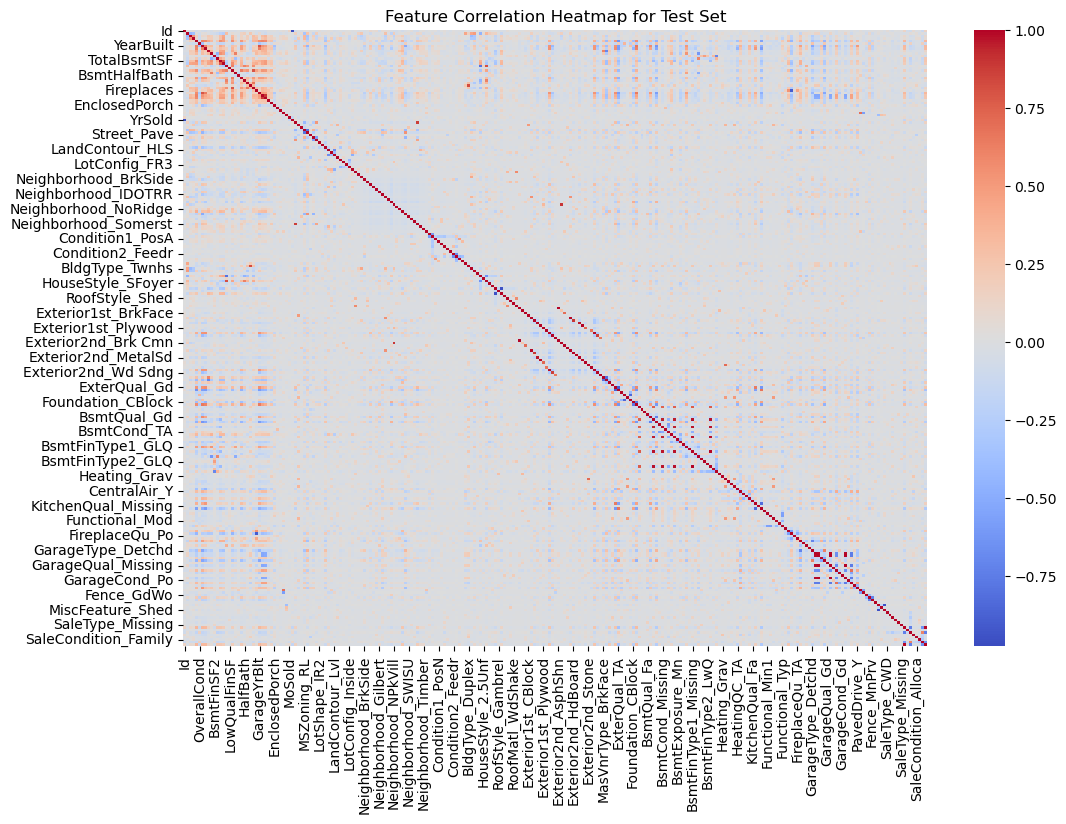

In [23]:
# correlation heatmap to check for multicollinearity

import seaborn as sns
import matplotlib.pyplot as plt

# computing correlation matrix
corr_matrix2 = test_df.corr()

# sorting correlated pairs from most to least correlated 
high_corr_pairs2 = corr_matrix2.abs().unstack().sort_values(ascending=False)

# removing self-correlations 
high_corr_pairs2 = high_corr_pairs2[high_corr_pairs2 < 1]

# setting |0.6| as the threshold from strong correlations 
high_corr_pairs2 = high_corr_pairs2[high_corr_pairs2 > 0.6]

num_high_corr_pairs2 = high_corr_pairs2.shape[0] // 2 # each pair appears twice, so divide by 2

print("Highly Correlated Feature Pairs (>|0.6|):")
print(high_corr_pairs2)

# getting set of individual features are in high correlation pairs by
# creating set of the first features from each correlated pair, and a set of the second features,
# then creating a union of both sets for all unique features
unique_high_corr_features2 = set(high_corr_pairs2.index.get_level_values(0)) | set(high_corr_pairs2.index.get_level_values(1))

# counting unique high-correlation features
num_unique_features2 = len(unique_high_corr_features2)

print(f"Total number of unique features with high correlations (test dataset): {num_unique_features2}")

# plotting heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix2, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap for Test Set")
plt.show()

In [24]:
# ensuring features consistency between training and testing data

feature_columns = X_train.columns


test_df = test_df.reindex(columns=feature_columns, fill_value=0) # if a col is missing, fill with 0

test_df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1461,20,80.0,11622,5,6,1961,1961,0.0,468.0,...,0,0,0,0,1,0,0,0,1,0
1,1462,20,81.0,14267,6,6,1958,1958,108.0,923.0,...,0,0,0,0,1,0,0,0,1,0
2,1463,60,74.0,13830,5,5,1997,1998,0.0,791.0,...,0,0,0,0,1,0,0,0,1,0
3,1464,60,78.0,9978,6,6,1998,1998,20.0,602.0,...,0,0,0,0,1,0,0,0,1,0
4,1465,120,43.0,5005,8,5,1992,1992,0.0,263.0,...,0,0,0,0,1,0,0,0,1,0


In [25]:
# making final predictions on test data - Random Forest

rf_predictions = best_rf_model.predict(test_df)

test_ids = test_df["Id"]
submission = pd.DataFrame({"Id": test_ids, "SalePrice": rf_predictions})
print(submission)

submission.to_csv("submission.csv", index=False)

        Id      SalePrice
0     1461  128365.159279
1     1462  155033.025899
2     1463  182348.794655
3     1464  184219.814587
4     1465  199900.190920
...    ...            ...
1454  2915   85503.268758
1455  2916   86872.907793
1456  2917  153694.415294
1457  2918  113230.269846
1458  2919  226315.749906

[1459 rows x 2 columns]


In [26]:
# making final predictions on test data - Ridge Regression 